# Diffusion Models

A refresher on **denoising diffusion probabilistic models (DDPMs)** — the generative
family behind Stable Diffusion, Imagen, and most modern image/audio/video synthesis.

**Domain:** Architectures  ·  **runnable:** yes

## 1. What & Why

A diffusion model learns to **generate data by reversing a gradual noising process**.
You take real data, destroy it step by step with Gaussian noise until it's pure static,
then train a neural network to undo one step of that destruction. Sampling = start from
pure noise and run the learned denoiser backward until a clean sample emerges.

**The problem it solves.** Generative modeling is hard because you must turn a simple
distribution (Gaussian noise) into a complex one (faces, audio, molecules). GANs do this
in one shot with an adversarial game that is unstable and mode-collapse-prone. VAEs are
stable but blurry. Diffusion breaks the hard jump into *hundreds of tiny, easy denoising
steps*, each trained with a plain regression (MSE) loss. The result: stable training,
state-of-the-art sample quality, and excellent mode coverage.

**Reach for it when** you want high-fidelity, diverse generation (images, audio, video,
3D, molecules) and can afford multi-step sampling. **Avoid it when** you need single-pass
real-time generation or a tractable exact likelihood — diffusion sampling is inherently
iterative (though distillation and few-step solvers narrow the gap). See
[Flow Matching](flow-matching.ipynb) and [Normalizing Flows](normalizing-flows.ipynb)
for related continuous-time and exact-likelihood alternatives.

## 2. Mental Model

**A drop of ink in water, played backward.**

Forward (fixed, no learning): a sharp image is like a drop of ink. Each timestep stirs in
a little Gaussian noise. After enough steps the ink is fully diffused — indistinguishable
from a glass of plain noisy water. This *forward process* `q` has a convenient property:
you can jump to **any** noise level `t` in closed form, without simulating every step.

Reverse (learned): the network watches noisy water at level `t` and predicts *which way to
un-stir* — i.e. it estimates the noise that was added. Subtract a calibrated amount, add a
touch of fresh noise, and you've moved one step toward a clean image. Run that 1000→0 and
the ink reassembles into a brand-new picture the model has never seen.

```
x0  --q-->  x1  --q-->  ...  --q-->  xT   (= pure noise)   [forward: fixed Gaussian noising]
x0 <--pθ--  x1 <--pθ--  ...  <--pθ--  xT                   [reverse: learned denoiser]
```

The single equation that makes the forward jump cheap (with α̅_t = ∏(1−β_s)):

    x_t = √(α̅_t) · x_0  +  √(1 − α̅_t) · ε,     ε ~ N(0, I)

## 3. Key Concepts

- **Forward / noising process `q`** — fixed Markov chain that adds Gaussian noise per step
  with variance schedule `β_t`. No learnable parameters.
- **Noise schedule (`β_t`)** — how fast noise is injected. Linear, cosine (Nichol & Dhariwal),
  or sigmoid. Cosine keeps more signal at high `t` and usually trains better.
- **`α̅_t` (alpha-bar / cumulative product)** — the survival fraction of the original signal
  at step `t`. Lets you sample `x_t` directly from `x_0` in one shot (the equation above).
- **Reverse process `p_θ`** — the learned denoiser. Predicts the noise `ε` (the standard
  *ε-prediction* parameterization), from which the posterior mean of `x_{t−1}` is computed.
- **Training objective** — a simple weighted MSE: sample a random `t`, noise `x_0` to `x_t`,
  ask the network to predict the noise, regress to the true `ε`. That's the whole loss.
- **Sampler** — the reverse-time integrator. **DDPM** is stochastic and slow (~1000 steps);
  **DDIM** is deterministic and skips steps (~20–50); **DPM-Solver** is a high-order ODE
  solver (~10–20 steps). Same trained model, swappable sampler.
- **Score / `ε` / `v` parameterizations** — equivalent views: predicting noise `ε`,
  predicting the score `∇ log p(x_t)` (they differ only by a scale), or `v`-prediction
  (Salimans & Ho), which is more stable near `t=0` and `t=T`.
- **Classifier-free guidance (CFG)** — train with conditioning randomly dropped; at sample
  time push toward `ε_cond` and away from `ε_uncond` to trade diversity for prompt fidelity.
- **Latent diffusion** — run diffusion in a VAE's compressed latent space instead of pixels.
  This is what makes Stable Diffusion tractable on a single GPU.

## 4. Setup

Pure CPU PyTorch — no GPU, no downloads. The worked examples train a tiny denoiser on 2-D
toy data in a few seconds.

```bash
%pip install torch numpy matplotlib
# Optional, only for the gated real-model demo at the end:
%pip install "diffusers[torch]" transformers accelerate
```

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
print("torch", torch.__version__, "| running on CPU")

torch 2.12.1 | running on CPU


## 5. Worked Examples

### Example 1 — The forward process in closed form

Define a linear `β` schedule, accumulate it into `α̅_t`, and verify the one-shot noising
equation. The key takeaway: at `t=0` the signal is intact; by the final step `√α̅_t ≈ 0`,
so `x_T` is essentially pure `N(0, I)` noise — exactly the prior we sample from.

In [2]:
T = 1000                                  # number of diffusion steps (standard DDPM)
betas = torch.linspace(1e-4, 0.02, T)     # linear noise schedule
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)   # alpha-bar_t

def q_sample(x0, t, noise):
    """One-shot forward: x_t = sqrt(abar_t)*x0 + sqrt(1-abar_t)*eps."""
    abar = alphas_cumprod[t]
    return torch.sqrt(abar) * x0 + torch.sqrt(1 - abar) * noise

x0 = torch.tensor([2.0])
print(f"{'t':>4} {'sqrt(abar)':>11} {'noise frac':>11} {'x_t':>9}")
for t in [0, 250, 500, 750, 999]:
    xt = q_sample(x0, t, torch.randn(1))
    print(f"{t:>4} {alphas_cumprod[t].sqrt():>11.3f} "
          f"{(1-alphas_cumprod[t]).sqrt():>11.3f} {xt.item():>+9.3f}")

print(f"\nsignal retained at final step: {alphas_cumprod[-1].sqrt().item():.4f}  "
      "(≈ 0 → x_T is essentially pure noise)")

   t  sqrt(abar)  noise frac       x_t
   0       1.000       0.010    +2.015
 250       0.722       0.692    +1.241
 500       0.279       0.960    -1.534
 750       0.057       0.998    +0.682
 999       0.006       1.000    -1.072

signal retained at final step: 0.0064  (≈ 0 → x_T is essentially pure noise)


### Example 2 — Train a tiny DDPM and sample from it

A full DDPM on 2-D *two-moons* data: an MLP predicts the noise `ε` given `(x_t, t)`, trained
with MSE. Then we run **ancestral sampling** — start from `N(0, I)` and denoise step by step
back to `t=0`. The generated points should reproduce the two-crescent shape, demonstrating
that the model learned the data distribution, not just memorized points.

In [3]:
def make_moons(n):
    """Two interleaving half-circles (no sklearn dependency)."""
    k = n // 2
    a = np.linspace(0, np.pi, k)
    outer = np.stack([np.cos(a), np.sin(a)], 1)
    inner = np.stack([1 - np.cos(a), 0.5 - np.sin(a)], 1)
    x = np.concatenate([outer, inner], 0) + 0.06 * np.random.randn(2 * k, 2)
    return x.astype(np.float32)

raw = make_moons(2000)
mean, std = raw.mean(0), raw.std(0)
X = torch.from_numpy((raw - mean) / std)        # standardize to ~N(0,1) marginals
print("dataset:", X.shape, "| per-dim std:", X.std(0).numpy().round(2))

dataset: torch.Size([2000, 2]) | per-dim std: [1. 1.]


In [4]:
class Denoiser(nn.Module):
    """Predicts the noise eps from a noised point x_t and its timestep t."""
    def __init__(self, dim=2, h=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, h), nn.SiLU(),
            nn.Linear(h, h), nn.SiLU(),
            nn.Linear(h, dim),
        )
    def forward(self, x, t):
        tt = (t.float() / T).view(-1, 1)        # timestep -> [0, 1]
        return self.net(torch.cat([x, tt], dim=1))

model = Denoiser()
opt = torch.optim.Adam(model.parameters(), lr=2e-3)

for step in range(3000):
    x0 = X[torch.randint(0, len(X), (256,))]
    t = torch.randint(0, T, (256,))
    noise = torch.randn_like(x0)
    abar = alphas_cumprod[t].view(-1, 1)
    xt = torch.sqrt(abar) * x0 + torch.sqrt(1 - abar) * noise   # forward q_sample
    loss = ((model(xt, t) - noise) ** 2).mean()                 # DDPM loss = MSE on eps
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 500 == 0:
        print(f"step {step:>4}  loss {loss.item():.4f}")
print("final loss:", round(loss.item(), 4))

step    0  loss 0.9959


step  500  loss 0.2924


step 1000  loss 0.2484


step 1500  loss 0.2262


step 2000  loss 0.2508


step 2500  loss 0.2362


final loss: 0.2125


generated mean: [-0.03  0.01] | std: [0.98 1.03] (target ~[0,0] / ~[1,1])


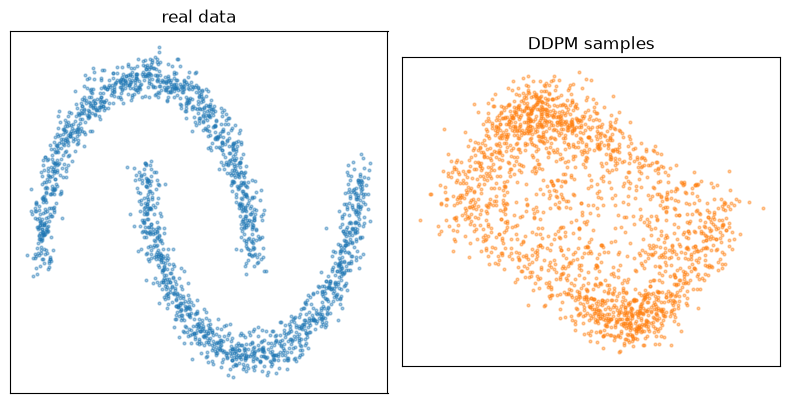

In [5]:
@torch.no_grad()
def ddpm_sample(n):
    """Ancestral sampling: x_T ~ N(0,I) -> ... -> x_0."""
    x = torch.randn(n, 2)
    for t in reversed(range(T)):
        tb = torch.full((n,), t, dtype=torch.long)
        eps = model(x, tb)
        beta, abar, alpha = betas[t], alphas_cumprod[t], alphas[t]
        mean = (x - beta / torch.sqrt(1 - abar) * eps) / torch.sqrt(alpha)
        x = mean + (torch.sqrt(beta) * torch.randn_like(x) if t > 0 else 0.0)
    return x.numpy()

gen = ddpm_sample(2000)
print("generated mean:", gen.mean(0).round(2), "| std:", gen.std(0).round(2),
      "(target ~[0,0] / ~[1,1])")

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].scatter(X[:, 0], X[:, 1], s=4, alpha=0.4); ax[0].set_title("real data")
ax[1].scatter(gen[:, 0], gen[:, 1], s=4, alpha=0.4, color="C1")
ax[1].set_title("DDPM samples")
for a in ax: a.set_aspect("equal"); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

### Example 3 — Using a real pretrained model (gated)

Toy data shows the mechanics; production diffusion uses **latent diffusion** with a U-Net
denoiser, text conditioning, and a fast sampler. The call shape below is all you need — it's
gated behind an env var so this notebook still runs without the ~4 GB download.

In [6]:
# Set RUN_DIFFUSERS=1 to actually download + run Stable Diffusion (large, GPU recommended).
if os.getenv("RUN_DIFFUSERS"):
    from diffusers import StableDiffusionPipeline
    pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5")
    image = pipe("a watercolor fox, soft light", num_inference_steps=25).images[0]
    image.save("fox.png")
    print("saved fox.png")
else:
    print("Skipped real model (set RUN_DIFFUSERS=1 to enable). Call shape:")
    print('  from diffusers import StableDiffusionPipeline')
    print('  pipe  = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5")')
    print('  image = pipe("a watercolor fox", num_inference_steps=25).images[0]')

Skipped real model (set RUN_DIFFUSERS=1 to enable). Call shape:
  from diffusers import StableDiffusionPipeline
  pipe  = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5")
  image = pipe("a watercolor fox", num_inference_steps=25).images[0]


## 6. Gotchas & Pitfalls

- **Forgetting to standardize / scale data.** The model assumes `x_T ≈ N(0, I)`. If your
  data isn't roughly zero-mean unit-variance (pixels are typically mapped to `[-1, 1]`),
  the schedule never fully noises it and samples drift.
- **Schedule mismatch.** A linear schedule on small images wastes steps at high `t` where
  everything is already noise. Cosine schedules fix this — a frequent quality win for free.
- **Confusing the parameterizations.** ε-prediction, score, and `v`-prediction are
  interchangeable but use *different* loss/sampler formulas. Mixing equations from two
  conventions produces garbage. Pick one and stay consistent.
- **Too few sampling steps with the wrong sampler.** DDPM ancestral sampling looks bad
  under ~100 steps; DDIM/DPM-Solver give comparable quality in 20–50. Don't blame the model
  for a sampler problem.
- **Numerical issues at the endpoints.** `√(1 − α̅_t)` → 0 as `t` → 0 causes divisions to
  blow up. Clip, use `v`-prediction, or stop the reverse loop's noise injection at `t=0`
  (as the example does).
- **Over-strong classifier-free guidance.** High CFG scales boost prompt adherence but
  oversaturate colors and collapse diversity. Typical sweet spot is ~5–8 for images.
- **Cost of training.** Diffusion needs to see every noise level, so it's data- and
  compute-hungry compared to a GAN of similar quality. Plan for long training runs.

## 7. When to Use vs Alternatives

| Approach | Sample quality | Sampling speed | Training stability | Exact likelihood | Notes |
|---|---|---|---|---|---|
| **Diffusion (DDPM)** | Excellent | Slow (iterative) | Very stable | No (variational bound) | Best all-round image/audio/video quality; mode coverage |
| **GAN** | High | Fast (1 pass) | Unstable, mode collapse | No | Real-time, but tricky to train; see [GAN](gan.ipynb) |
| **VAE** | Blurry | Fast (1 pass) | Stable | Lower bound | Great for representation learning; see [VAE](vae.ipynb) |
| **Normalizing flows** | Good | Fast | Stable | **Exact** | Invertible; exact likelihood; see [Normalizing Flows](normalizing-flows.ipynb) |
| **Flow matching** | Excellent | Fast (few steps) | Very stable | No | Continuous-time cousin; straighter paths → fewer steps; see [Flow Matching](flow-matching.ipynb) |
| **Autoregressive** | Excellent | Very slow | Stable | **Exact** | Token-by-token (images/audio); strong but sequential |

**Rules of thumb.** Default to **diffusion** for high-fidelity, diverse generation when you
can afford multi-step sampling — and use a fast sampler (DDIM/DPM-Solver) plus latent-space
diffusion to make it practical. Choose a **GAN** when you need single-pass real-time output.
Choose **flows** or **autoregressive** when you genuinely need exact likelihoods. **Flow
matching** is the modern challenger: same quality, often fewer steps, and increasingly the
default for new large-scale generative systems.

## 8. Resources

- **Ho, Jain & Abbeel — Denoising Diffusion Probabilistic Models (2020)**, the foundational
  DDPM paper: https://arxiv.org/abs/2006.11239
- **Song et al. — DDIM (Denoising Diffusion Implicit Models, 2021)**, fast deterministic
  sampling: https://arxiv.org/abs/2010.02502
- **Rombach et al. — Latent Diffusion / Stable Diffusion (2022)**:
  https://arxiv.org/abs/2112.10752
- **Lilian Weng — "What are Diffusion Models?"**, the best single explainer with full math:
  https://lilianweng.github.io/posts/2021-07-11-diffusion-models/
- **Hugging Face Diffusers docs** — production library, samplers, pipelines:
  https://huggingface.co/docs/diffusers
- **The Annotated Diffusion Model** — DDPM implemented line by line in PyTorch:
  https://huggingface.co/blog/annotated-diffusion